# 8주차: 로지스틱 회귀 I — 시그모이드 유도, BCE와 MLE의 연결
> 인공지능수학 | 영상 강의용 노트북

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

---
## 🔮 Aha Moment — 먼저 결과를 보세요.


아래 코드를 실행하면 S자 곡선이 두 클래스 사이에 깔끔하게 놓입니다.  

**세 가지 질문이 생깁니다:**
1. 왜 이 S자 곡선(시그모이드)을 쓰는가? 다른 곡선은 안 되는가?
2. 손실함수 `(y_hat - y)`는 어디서 나왔는가?
3. 7주차에서 배운 MLE와 이 손실함수는 어떤 관계인가?

오늘 수업이 끝나면 세 질문 모두 수학적으로 답할 수 있게 됩니다.

---

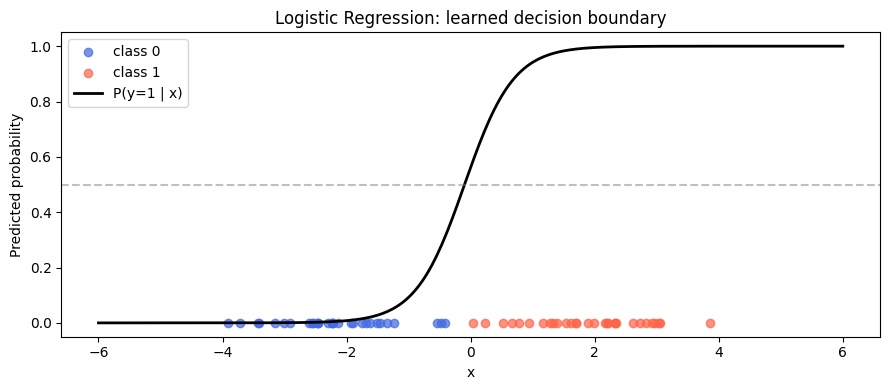

학습된 파라미터: w = 2.532, b = 0.248
결정 경계(P=0.5): x = -0.098


In [ ]:
np.random.seed(42)

# Simple 1D classification dataset
X_neg = np.random.randn(30) - 2    # class 0
X_pos = np.random.randn(30) + 2    # class 1
X = np.concatenate([X_neg, X_pos])
y = np.array([0]*30 + [1]*30)

# Logistic regression with BCE (we will derive this today)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Gradient descent
w, b = 0.0, 0.0
lr = 0.1
for _ in range(300):
    z = w * X + b
    y_hat = sigmoid(z)
    dw = ((y_hat - y) * X).mean()
    db = (y_hat - y).mean()
    w -= lr * dw
    b -= lr * db

x_line = np.linspace(-6, 6, 300)
prob_line = sigmoid(w * x_line + b)

plt.figure(figsize=(9, 4))
plt.scatter(X_neg, np.zeros(30), color='royalblue', label='class 0', alpha=0.7)
plt.scatter(X_pos, np.zeros(30), color='tomato',    label='class 1', alpha=0.7)
plt.plot(x_line, prob_line, 'k-', linewidth=2, label='P(y=1 | x)')
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('x')
plt.ylabel('Predicted probability')
plt.title('Logistic Regression: learned decision boundary')
plt.legend()
plt.tight_layout()
plt.show()

print(f"학습된 파라미터: w = {w:.3f}, b = {b:.3f}")
print(f"결정 경계(P=0.5): x = {-b/w:.3f}")

---
## 1. 분류 문제와 선형 회귀의 한계

### 1.1 분류란 무엇인가?

회귀(Regression)는 연속값을 예측합니다: $\hat{y} \in \mathbb{R}$  
분류(Classification)는 이산 레이블을 예측합니다: $y \in \{0, 1\}$ (이진 분류)

목표를 바꿔봅시다.  
예측값을 직접 0 또는 1로 만들기보다, **$y=1$일 확률**을 모델링합니다:

$$\hat{p} = P(y=1 \mid x)$$

확률이므로 반드시 $0 \leq \hat{p} \leq 1$이어야 합니다.

### 1.2 선형 회귀를 그대로 쓰면?

$$\hat{p} = wx + b$$

이 식은 $x$가 매우 크거나 작을 때 $\hat{p} > 1$ 또는 $\hat{p} < 0$이 됩니다.  
확률의 정의에 위배됩니다.

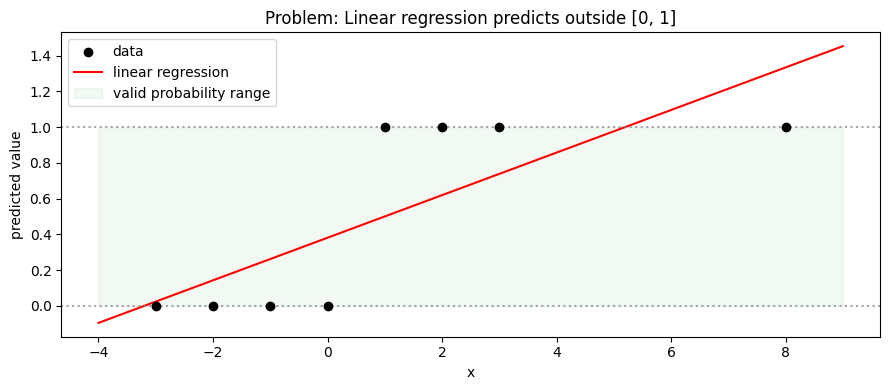

x = -4 일 때 선형 예측값: -0.095 ← 음수!
x =  9 일 때 선형 예측값: 1.452 ← 1 초과!


In [ ]:
# Problem with linear regression for classification
np.random.seed(0)
X_demo = np.array([-3, -2, -1, 0, 1, 2, 3, 8])   # extreme outlier at 8
y_demo = np.array([0,   0,  0, 0, 1, 1, 1, 1])

# Fit linear regression manually
X_b = np.column_stack([X_demo, np.ones(len(X_demo))])
w_lin = np.linalg.lstsq(X_b, y_demo, rcond=None)[0]

x_line = np.linspace(-4, 9, 200)
y_lin  = w_lin[0] * x_line + w_lin[1]

plt.figure(figsize=(9, 4))
plt.scatter(X_demo, y_demo, color='black', zorder=5, label='data')
plt.plot(x_line, y_lin, 'r-', label='linear regression')
plt.axhline(0, color='gray', linestyle=':', alpha=0.7)
plt.axhline(1, color='gray', linestyle=':', alpha=0.7)
plt.fill_between(x_line, 0, 1, alpha=0.05, color='green', label='valid probability range')
plt.xlabel('x')
plt.ylabel('predicted value')
plt.title('Problem: Linear regression predicts outside [0, 1]')
plt.legend()
plt.tight_layout()
plt.show()

# Show that extreme x gives invalid probability
print("x = -4 일 때 선형 예측값:", round(w_lin[0]*(-4) + w_lin[1], 3), "← 음수!")
print("x =  9 일 때 선형 예측값:", round(w_lin[0]*(9)  + w_lin[1], 3), "← 1 초과!")

---
## 2. 시그모이드 함수(Sigmoid Function) 유도

### 2.1 아이디어: 오즈(Odds)와 로짓(Logit)

확률 $p$를 직접 선형 모델로 쓸 수 없다면, **변환**을 통해 $(-\infty, +\infty)$ 범위로 펼쳐봅시다.

**Step 1 — 오즈(Odds)**: 확률 $p \in [0,1]$를 $[0, +\infty)$로 확장
$$\text{Odds} = \frac{p}{1-p}$$

- $p = 0.5$ → Odds $= 1$ (동등한 가능성)
- $p = 0.9$ → Odds $= 9$ (성공이 실패보다 9배 가능)
- $p \to 1$  → Odds $\to +\infty$

**Step 2 — 로짓(Logit)**: 로그를 취해 $(-\infty, +\infty)$로 확장
$$\text{logit}(p) = \log\frac{p}{1-p}$$

- $p = 0.5$ → logit $= 0$
- $p \to 0$  → logit $\to -\infty$
- $p \to 1$  → logit $\to +\infty$

**Step 3 — 선형 모델로 logit을 예측**:
$$\log\frac{p}{1-p} = wx + b$$

이제 우변은 어떤 실수도 될 수 있습니다.

**Step 4 — $p$에 대해 역으로 풀기**: $z = wx + b$로 놓으면
$$\frac{p}{1-p} = e^z \implies p = \frac{e^z}{1 + e^z} = \frac{1}{1 + e^{-z}}$$

$$\boxed{\sigma(z) = \frac{1}{1+e^{-z}}}$$

이것이 **시그모이드 함수(Sigmoid Function)** 입니다.  
임의로 선택한 함수가 아니라, "확률을 선형 모델로 예측하겠다"는 논리적 요구에서 **필연적으로** 도출됩니다.

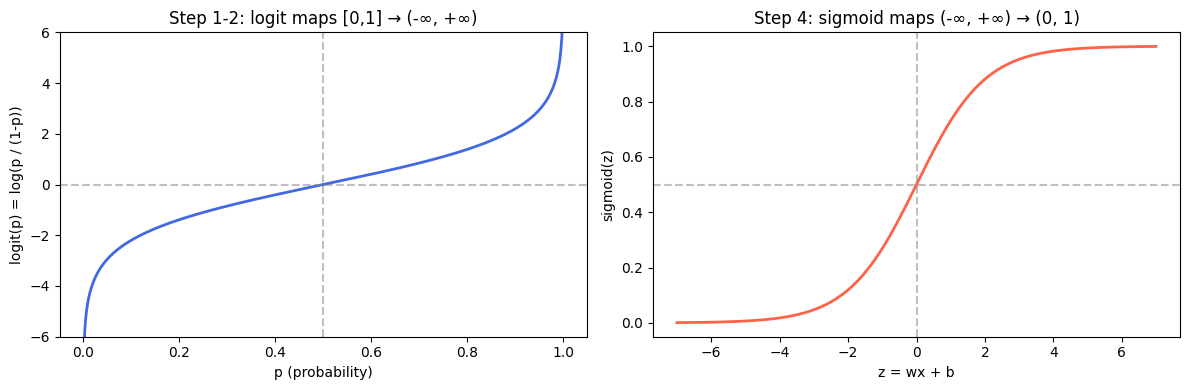

logit과 sigmoid는 서로 역함수 관계입니다.
sigmoid(0)   = 0.500  (z=0 → p=0.5)
sigmoid(2)   = 0.881
sigmoid(-2)  = 0.119


In [ ]:
# Visualize the logit transform and sigmoid
p = np.linspace(0.001, 0.999, 500)
logit_p = np.log(p / (1 - p))

z = np.linspace(-7, 7, 500)
sigmoid_z = 1 / (1 + np.exp(-z))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: logit
axes[0].plot(p, logit_p, 'royalblue', linewidth=2)
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('p (probability)')
axes[0].set_ylabel('logit(p) = log(p / (1-p))')
axes[0].set_title('Step 1-2: logit maps [0,1] → (-∞, +∞)')
axes[0].set_ylim(-6, 6)

# Right: sigmoid (inverse of logit)
axes[1].plot(z, sigmoid_z, 'tomato', linewidth=2)
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(0,   color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('z = wx + b')
axes[1].set_ylabel('sigmoid(z)')
axes[1].set_title('Step 4: sigmoid maps (-∞, +∞) → (0, 1)')
axes[1].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

print("logit과 sigmoid는 서로 역함수 관계입니다.")
print(f"sigmoid(0)   = {1/(1+np.exp(0)):.3f}  (z=0 → p=0.5)")
print(f"sigmoid(2)   = {1/(1+np.exp(-2)):.3f}")
print(f"sigmoid(-2)  = {1/(1+np.exp(2)):.3f}")

### 2.2 시그모이드의 핵심 성질

$$\sigma(z) = \frac{1}{1+e^{-z}}$$

| 성질 |&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 수식 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | 의미 |
|---|---|---|
| 범위 | $0 < \sigma(z) < 1$ | 항상 유효한 확률 |
| 대칭 | $\sigma(-z) = 1 - \sigma(z)$ | 중심 대칭 |
| 미분 | $\sigma'(z) = \sigma(z)(1-\sigma(z))$ | 자기 자신으로 표현 — 10주차에서 핵심 |

**미분 유도:**
$$\sigma'(z) = \frac{e^{-z}}{(1+e^{-z})^2} = \frac{1}{1+e^{-z}} \cdot \frac{e^{-z}}{1+e^{-z}} = \sigma(z) \cdot (1 - \sigma(z))$$

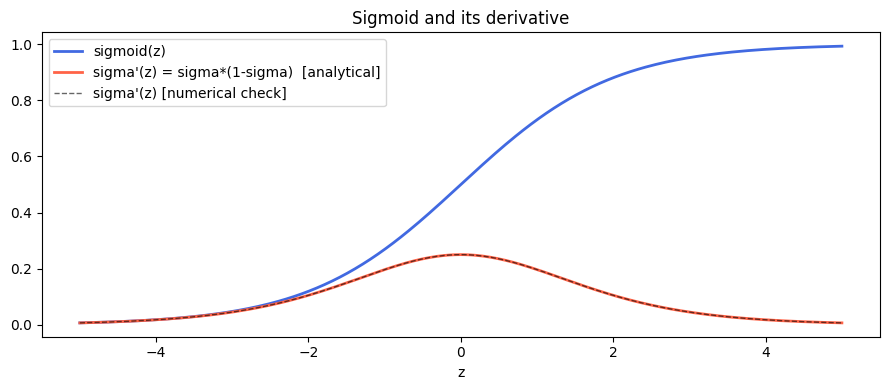

해석적 미분 vs 수치 미분 최대 오차: 1.08e-11  ← 일치 확인!


In [ ]:
# Verify sigmoid derivative: sigma'(z) = sigma(z) * (1 - sigma(z))
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_vals = np.linspace(-5, 5, 300)
h = 1e-5

# Analytical derivative
sig      = sigmoid(z_vals)
d_sig_analytical = sig * (1 - sig)

# Numerical derivative
d_sig_numerical  = (sigmoid(z_vals + h) - sigmoid(z_vals - h)) / (2 * h)

plt.figure(figsize=(9, 4))
plt.plot(z_vals, sig,                'royalblue', linewidth=2,  label='sigmoid(z)')
plt.plot(z_vals, d_sig_analytical,   'tomato',    linewidth=2,  label="sigma'(z) = sigma*(1-sigma)  [analytical]")
plt.plot(z_vals, d_sig_numerical,    'k--',       linewidth=1,  label="sigma'(z) [numerical check]", alpha=0.6)
plt.xlabel('z')
plt.title('Sigmoid and its derivative')
plt.legend()
plt.tight_layout()
plt.show()

max_diff = np.max(np.abs(d_sig_analytical - d_sig_numerical))
print(f"해석적 미분 vs 수치 미분 최대 오차: {max_diff:.2e}  ← 일치 확인!")

---
## 3. 로지스틱 회귀 모델 정의

### 3.1 모델 수식

$$z = wx + b \qquad (\text{선형 결합, linear combination})$$
$$\hat{p} = \sigma(z) = \frac{1}{1 + e^{-z}} \qquad (\text{확률 예측})$$

예측 레이블:
$$\hat{y} = \begin{cases} 1 & \hat{p} \geq 0.5 \\ 0 & \hat{p} < 0.5 \end{cases}$$

$\hat{p} = 0.5$이면 $\sigma(z) = 0.5 \implies z = 0 \implies wx + b = 0$  
이 선이 **결정 경계(Decision Boundary)** 입니다.

### 3.2 확률적 해석

로지스틱 회귀는 $x$가 주어졌을 때 $y$의 **조건부 확률**을 직접 모델링합니다:

$$P(y=1 \mid x) = \hat{p}= \sigma(wx+b)$$
$$P(y=0 \mid x) = 1 - \sigma(wx+b)$$

두 식을 하나로 합치면:
$$P(y \mid x) = \hat{p}^{\,y} \cdot (1-\hat{p})^{1-y}, \quad y \in \{0,1\}$$

> 이 마지막 표현식을 기억해두세요 — MLE와 연결되는 핵심 식입니다.

In [ ]:
# Verify the unified probability expression
p_hat = 0.8   # model's predicted probability

# P(y|x) = p_hat^y * (1-p_hat)^(1-y)
for y in [0, 1]:
    prob = (p_hat**y) * ((1 - p_hat)**(1 - y))
    print(f"y={y}: P(y|x) = {p_hat}^{y} * {1-p_hat:.1f}^{1-y} = {prob:.3f}")

print()
print("y=1이면 p_hat을 그대로, y=0이면 (1-p_hat)을 반환하는 우아한 표현식입니다.")

y=0: P(y|x) = 0.8^0 * 0.2^1 = 0.200
y=1: P(y|x) = 0.8^1 * 0.2^0 = 0.800

y=1이면 p_hat을 그대로, y=0이면 (1-p_hat)을 반환하는 우아한 표현식입니다.


---
## 4. 손실함수 유도: MLE → BCE

### 4.1 이진 분류의 우도함수

7주차에서 MLE를 배웠습니다.  
**"관측된 데이터를 가장 그럴듯하게 만드는 파라미터를 찾아라."**

$n$개의 독립적인 훈련 데이터 $(x_1,y_1), \ldots, (x_n, y_n)$에 대한 우도:

$$L(w,b) = \prod_{i=1}^n P(y_i \mid x_i) = \prod_{i=1}^n \hat{p}_i^{\,y_i} (1-\hat{p}_i)^{1-y_i}$$

여기서 $\hat{p}_i = \sigma(wx_i + b)$입니다.

### 4.2 log-likelihood

7주차와 동일하게, 곱을 합으로 바꾸기 위해 로그를 취합니다:

$$\ell(w,b) = \sum_{i=1}^n \left[ y_i \log \hat{p}_i + (1-y_i)\log(1-\hat{p}_i) \right]$$

### 4.3 최대화 → 최소화

경사하강법은 **최소화**를 수행합니다.  
log-likelihood를 **최대화**하는 것은 **negative log-likelihood를 최소화**하는 것과 동일:

$$\min_{w,b} \mathcal{L}_{\text{BCE}} = -\frac{1}{n}\sum_{i=1}^n \left[ y_i \log \hat{p}_i + (1-y_i)\log(1-\hat{p}_i) \right]$$

이것이 **이진 교차엔트로피(BCE, Binary Cross-Entropy)** 손실함수입니다.

$$\boxed{\text{BCE 최소화} = \text{MLE 최대화}}$$

**BCE는 새로운 개념이 아닙니다. 7주차 MLE의 직접적인 결과입니다.**

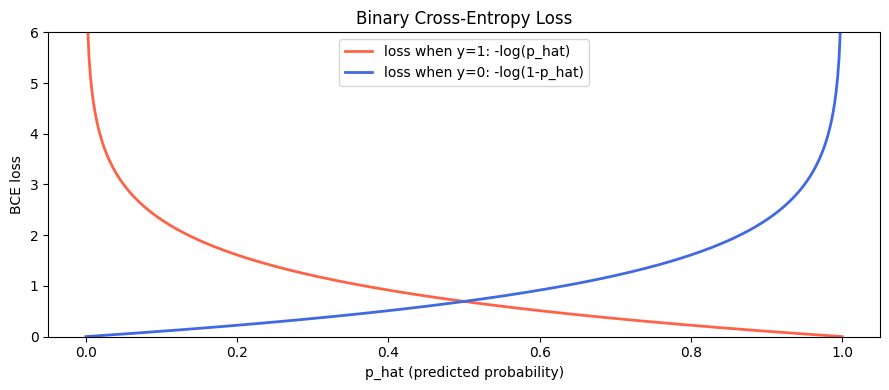

y=1인데 p_hat→0을 예측: loss → 16.1 (매우 큰 손실)
y=1인데 p_hat→1을 예측: loss → 0.0 (손실 ≈ 0)


In [ ]:
# Visualize BCE loss: what does it penalize?
p_hat = np.linspace(1e-7, 1-1e-7, 500)

loss_y1 = -np.log(p_hat)       # loss when true label y=1
loss_y0 = -np.log(1 - p_hat)   # loss when true label y=0

plt.figure(figsize=(9, 4))
plt.plot(p_hat, loss_y1, 'tomato',    linewidth=2, label='loss when y=1: -log(p_hat)')
plt.plot(p_hat, loss_y0, 'royalblue', linewidth=2, label='loss when y=0: -log(1-p_hat)')
plt.ylim(0, 6)
plt.xlabel('p_hat (predicted probability)')
plt.ylabel('BCE loss')
plt.title('Binary Cross-Entropy Loss')
plt.legend()
plt.tight_layout()
plt.show()

print("y=1인데 p_hat→0을 예측: loss →", round(float(-np.log(1e-7)), 1), "(매우 큰 손실)")
print("y=1인데 p_hat→1을 예측: loss →", round(float(-np.log(1-1e-7)), 1), "(손실 ≈ 0)")

### 4.4 BCE가 MSE보다 적합한 이유

분류에 MSE를 쓰면 어떤 문제가 생길까요?

$$\mathcal{L}_{\text{MSE}} = \frac{1}{n}\sum_{i=1}^n (\hat{p}_i - y_i)^2$$

- $\sigma(z)$를 출력에 씌우면 MSE의 gradient에 $\sigma'(z) = \sigma(z)(1-\sigma(z))$가 곱해집니다.
- $z$가 매우 크거나 작을 때(확신이 강할 때) $\sigma'(z) \approx 0$ → **gradient 소실(vanishing gradient)**
- BCE는 이 문제가 없습니다 — 10주차에서 gradient 유도를 통해 직접 확인합니다.

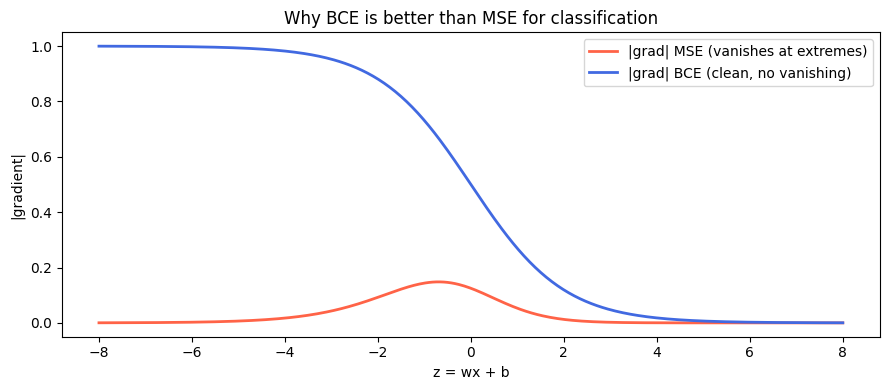

z=-8일 때 MSE gradient: -3.35e-04 ← 거의 0
z=-8일 때 BCE gradient: -0.9997 ← 상수 수준


In [ ]:
# Demonstrate vanishing gradient of MSE with sigmoid output
z = np.linspace(-8, 8, 400)
sig_z = sigmoid(z)

# For y=1:
# MSE gradient ∝ (sig(z) - 1) * sig'(z) = (sig-1) * sig*(1-sig)
# BCE gradient ∝ (sig(z) - 1)

grad_mse = (sig_z - 1) * sig_z * (1 - sig_z)   # d(MSE)/dz  for y=1
grad_bce = (sig_z - 1)                           # d(BCE)/dz  for y=1 (simplified)

plt.figure(figsize=(9, 4))
plt.plot(z, np.abs(grad_mse), 'tomato',    linewidth=2, label='|grad| MSE (vanishes at extremes)')
plt.plot(z, np.abs(grad_bce), 'royalblue', linewidth=2, label='|grad| BCE (clean, no vanishing)')
plt.xlabel('z = wx + b')
plt.ylabel('|gradient|')
plt.title('Why BCE is better than MSE for classification')
plt.legend()
plt.tight_layout()
plt.show()

print("z=-8일 때 MSE gradient:", f"{grad_mse[0]:.2e}",  "← 거의 0")
print("z=-8일 때 BCE gradient:", f"{grad_bce[0]:.4f}",  "← 상수 수준")

---
## 5. 전체 흐름 정리

$$\underbrace{\text{분류 문제}}_\text{목표} \xrightarrow{\text{확률 모델링}} \underbrace{P(y=1|x) = \sigma(wx+b)}_\text{시그모이드} \xrightarrow{\text{7주차 MLE}} \underbrace{\text{BCE 최소화}}_\text{손실함수}$$

| 단계 | 질문 | 답 |
|---|---|---|
| 왜 시그모이드? | 확률을 선형 모델로 예측하려면 | logit 변환의 역함수 → 필연적으로 도출 |
| 왜 BCE? | 최적 파라미터를 찾으려면 | 이진 분류 MLE의 negative log-likelihood |
| 왜 MSE 안 쓰나? | gradient 관점 | 극단 예측에서 gradient 소실 문제 |

## BCE  Loss 직관

$y=1$인 샘플은 $\hat p =1$에 가까운 값을 갖도록, $y=0$인 샘플은 $\hat p=0$에 가까운 값을 갖도록 하려 하지만 샘플이 여러개이므로 동시에 만족하는 $w, b$ 를 찾을 수는 없다. 그러므로 $-\log(p)$ 또는 $-\log(1-p)$ 로 심하게 틀렸을 때 큰 패널티를 주는 손실함수를 정의해서 모든 샘플에 대한 평균이 최소가 되도록 하는 것

* 모델의 "놀람(Surprise)"

**y = 1인 샘플 하나**를 예로 들면, loss = $-\log(p)$

| 모델 출력 $p$ |&nbsp;&nbsp;&nbsp;&nbsp; loss = $-\log(p)$ &nbsp;&nbsp;&nbsp;&nbsp;| 해석 |
|:---:|:---:|:---|
| 0.99 | ≈ 0.01 | 확신했고 맞음 → 거의 안 놀람 |
| 0.50 | ≈ 0.69 | 반반 → 좀 놀람 |
| 0.01 | ≈ 4.60 | 확신했는데 틀림 → **매우 놀람** |

> 틀릴수록, 그것도 **확신하며 틀릴수록** 패널티가 폭발적으로 커진다.

이는 정보이론의 **self-information** $I(x) = -\log p(x)$ 와 동일한 개념으로,  
확률이 낮다고 예측한 사건이 실제로 일어날수록 "놀람"이 크다는 직관에서 비롯된다.

전체 BCE Loss는 이 놀람의 **평균**:

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N} \left[ y_i \log p_i + (1-y_i)\log(1-p_i) \right]$$

학습 목표 = **"모든 샘플에 대해 평균적으로 가장 안 놀라는 $w, b$ 찾기"**

---
## 6. 익히기 활동 (25분)

### 빈칸 채우기 1 — 시그모이드 역산

시그모이드 함수의 대칭 성질 $\sigma(-z) = 1 - \sigma(z)$를 코드로 검증하세요.

In [ ]:
z_test = np.array([-3.0, -1.0, 0.0, 1.0, 3.0])

lhs = sigmoid(________)              # sigma(-z)
rhs = ________ - sigmoid(z_test)     # 1 - sigma(z)

print("z       :", z_test)
print("sigma(-z):", np.round(lhs, 4))
print("1-sigma(z):", np.round(rhs, 4))
print("일치하는가?", np.allclose(lhs, rhs))

### 빈칸 채우기 2 — BCE 손실 구현

이진 교차엔트로피 손실함수를 구현하세요.

In [ ]:
def bce_loss(y_true, y_pred):
    """
    Binary Cross-Entropy loss.
    y_true: array of 0s and 1s
    y_pred: array of predicted probabilities in (0, 1)
    """
    y_pred = np.clip(y_pred, 1e-12, 1 - 1e-12)   # avoid log(0)
    return ______  # -(y_true * log(y_pred) + (1-y_true) * log(1-y_pred)) 의 평균

# Test
y_true = np.array([1, 1, 0, 0])
y_pred_good = np.array([0.9, 0.8, 0.1, 0.2])   # good predictions
y_pred_bad  = np.array([0.1, 0.2, 0.9, 0.8])   # bad  predictions

print(f"좋은 예측의 BCE: {bce_loss(y_true, y_pred_good):.4f}")
print(f"나쁜 예측의 BCE: {bce_loss(y_true, y_pred_bad):.4f}")
print("좋은 예측의 손실 < 나쁜 예측의 손실 인가?", bce_loss(y_true, y_pred_good) < bce_loss(y_true, y_pred_bad))

### 빈칸 채우기 3 — 로지스틱 회귀 학습 루프

경사하강법으로 로지스틱 회귀를 학습하는 코드를 완성하세요.  
(gradient 공식의 유도는 10주차에서 하지만, 결과식은 오늘 사용합니다.)

BCE를 $w$에 대해 미분하면:
$$\frac{\partial \mathcal{L}}{\partial w} = \frac{1}{n}\sum_i (\hat{p}_i - y_i)x_i, \qquad \frac{\partial \mathcal{L}}{\partial b} = \frac{1}{n}\sum_i (\hat{p}_i - y_i)$$

In [ ]:
np.random.seed(7)
X_tr = np.concatenate([np.random.randn(50) - 1.5,
                        np.random.randn(50) + 1.5])
y_tr = np.array([0]*50 + [1]*50)

# Initialize
w, b = 0.0, 0.0
lr = 0.5
n  = len(y_tr)
losses = []

for epoch in range(200):
    # Forward pass
    z     = ______  # w * X_tr + b
    p_hat = ______  # sigmoid(z)

    # Loss
    loss = bce_loss(y_tr, p_hat)
    losses.append(loss)

    # Gradients
    dw = ((p_hat - y_tr) * X_tr).mean()
    db = (p_hat - y_tr).mean()

    # Update
    w -= lr * dw
    b -= lr * db

plt.figure(figsize=(9, 3))
plt.plot(losses, 'steelblue')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Training Loss')
plt.tight_layout()
plt.show()

print(f"최종 w = {w:.3f}, b = {b:.3f}")
print(f"결정 경계: x = {-b/w:.3f}")

### 🐛 버그 문제 — 교실에서 팀활동으로 해결!

아래 코드는 로지스틱 회귀를 학습하는데, 손실이 전혀 줄어들지 않고 약 0.693에 머뭅니다.  
**왜 이런 일이 생기는지 원인을 찾고 수정하세요.**

> 힌트: `0.693 ≈ log(2)` — 이것이 단서입니다.

In [ ]:
# 🐛 Bug: loss stays near 0.693 and never decreases
np.random.seed(1)
X_bug = np.concatenate([np.random.randn(40) - 2,
                         np.random.randn(40) + 2])
y_bug = np.array([0]*40 + [1]*40)

w_bug, b_bug = 0.0, 0.0
lr_bug = 0.1
losses_bug = []

for _ in range(150):
    z_bug   = w_bug * X_bug + b_bug
    p_bug   = sigmoid(z_bug)
    loss_b  = bce_loss(y_bug, p_bug)
    losses_bug.append(loss_b)

    dw = ((p_bug - y_bug) * X_bug).mean()
    db = (p_bug - y_bug).mean()

    w_bug += lr_bug * dw   # <-- 버그가 여기 있습니다
    b_bug += lr_bug * db

plt.figure(figsize=(8, 3))
plt.plot(losses_bug)
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Buggy training — why does loss not decrease?')
plt.tight_layout()
plt.show()

print(f"최종 손실: {losses_bug[-1]:.4f}  (log(2) = {np.log(2):.4f})")

---
## 7. LLM 파트너 가이드

**답을 바로 요청하지 마세요 — 내 생각을 먼저 설명하고 어디가 틀렸는지 물어보세요.**

---
**프롬프트 1: 시그모이드 유도 점검**
```
로지스틱 회귀에서 시그모이드 함수가 등장하는 과정을 내가 이해한 대로 설명할게.
"확률을 예측하고 싶은데, 확률은 0~1 사이여야 하므로
먼저 odds = p/(1-p)로 변환하고, 로그를 취해 logit = log(p/(1-p))을 만들어
이걸 선형 모델 wx+b로 예측한 뒤, 역으로 풀면 sigma(z)가 나온다."
이 설명에서 빠진 부분이나 틀린 부분이 있으면 알려줘. 정답은 주지 말고 힌트만.
```

---
**프롬프트 2: BCE = MLE 연결 점검**
```
BCE 손실함수가 MLE에서 나온다는 걸 공부했어.
내 이해: 각 데이터 포인트의 P(y|x)를 전부 곱한 것이 우도인데,
log를 취해 합으로 바꾸고, 부호를 뒤집으면 BCE가 된다.
이 설명이 수학적으로 맞나? 특히 "부호를 뒤집는" 부분의 이유를 내가 제대로 이해하고 있나?
```

---
**프롬프트 3: 버그 원인 추론 도움 요청**
```
로지스틱 회귀 학습 코드에서 손실이 log(2) ≈ 0.693에 수렴하고 변하지 않아.
내 추측: 파라미터가 전혀 업데이트되지 않는 것 같아.
왜 log(2)인지, 그리고 어떤 종류의 버그가 이 현상을 만드는지 힌트만 줘.
```

---

---
## 🔮 Aha Moment 닫기

수업 처음에 세 가지 질문을 던졌습니다.

1. **왜 시그모이드인가?**  
   확률($0\sim1$)을 선형 모델($-\infty \sim +\infty$)로 예측하려면 logit 변환이 필요하고, 그 역함수가 시그모이드입니다. 다른 함수가 아니라 이 함수여야 하는 수학적 이유가 있습니다.

2. **gradient `(y_hat - y)`는 어디서 나왔는가?**  
   BCE를 파라미터에 대해 미분한 결과입니다 — 10주차에서 chain rule로 직접 유도합니다.

3. **MLE와의 관계는?**  
   BCE = 이진 분류 MLE의 negative log-likelihood.  
   $\text{BCE 최소화} \equiv \text{MLE 최대화}$

---
## 다음 주 예고 — 10주차: 로지스틱 회귀 II

오늘 gradient 공식을 결과로만 사용했습니다:
$$\frac{\partial \mathcal{L}}{\partial w} = \frac{1}{n}\sum_i (\hat{p}_i - y_i)x_i$$

다음 주에는 이것을 chain rule로 직접 유도합니다:  
$\frac{\partial \mathcal{L}}{\partial w} = \frac{\partial \mathcal{L}}{\partial \hat{p}} \cdot \frac{\partial \hat{p}}{\partial z} \cdot \frac{\partial z}{\partial w}$  
그리고 $\sigma'(z) = \sigma(z)(1-\sigma(z))$가 핵심 역할을 합니다.